In [73]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [74]:
%run "02_data_cleaning (1).ipynb"

MQL exact duplicates: 0
Closed exact duplicates: 0
Orders exact duplicates: 0
Order Items exact duplicates: 0
Sellers exact duplicates: 0
Customers exact duplicates: 0
Reviews exact duplicates: 0
Duplicate order_id + order_item_id: 0
(98673, 2)
Duplicate order IDs: 0
Seller-order rows: (100010, 5)
Duplicate seller-order combinations: 0
Seller-order rows after orders merge: 100010
Missing order status: 0
Rows after review merge: 100010
Missing review scores: 763
Rows after seller merge: 100010
Missing seller state: 0
Missing seller city: 0
Delivered seller-order rows: 97819
Unique delivered sellers: 2970
Seller summary shape: (2970, 5)
Duplicate seller IDs: 0
Seller summary rows: 2970
Duplicate seller IDs: 0
Missing seller state: 0
Missing seller city: 0
Minimum orders: 1
Maximum orders: 1819
Minimum sales value: 6.5
Maximum sales value: 226987.93
Minimum review score: 1.0
Maximum review score: 5.0
MQL rows: 8000
Funnel rows: 8000
Converted sellers: 842
Duplicate seller IDs: 0
Converted

In [75]:
review_by_order = (reviews.groupby("order_id")["review_score"].mean().reset_index())
review_by_order

,order_id,review_score
0,00010242fe8c5a6d1ba2dd792cb16214,5.0
1,00018f77f2f0320c557190d7a144bdd3,4.0
2,000229ec398224ef6ca0657da4fc703e,5.0
3,00024acbcdf0a6daa1e931b038114c75,4.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,5.0
...,...,...
98668,fffc94f6ce00a00581880bf54a75a037,5.0
98669,fffcd46ef2263f404302a634eb57f7eb,5.0
98670,fffce4705a9662cd70adb13d4a31832d,5.0
98671,fffe18544ffabc95dfada21779c9644f,5.0


In [76]:
seller_order_level = ( order_items.groupby(["seller_id", "order_id"]).agg(
        order_value=("price", "sum"),
        freight_value=("freight_value", "sum"),
        item_count=("order_item_id", "count"),).reset_index())

In [77]:
seller_order_level

,seller_id,order_id,order_value,freight_value,item_count
0,0015a82c2db000af6aaaf3ae2ecb0532,7f39ba4c9052be115350065d07583cac,895.0,21.02,1
1,0015a82c2db000af6aaaf3ae2ecb0532,9dc8d1a6f16f1b89874c29c9d8d30447,895.0,21.02,1
2,0015a82c2db000af6aaaf3ae2ecb0532,d455a8cb295653b55abda06d434ab492,895.0,21.02,1
3,001cca7ae9ae17fb1caed9dfb1094831,006e43460a55bc60c0a437521e426529,99.0,43.06,1
4,001cca7ae9ae17fb1caed9dfb1094831,00dfb074b5c910fbd08e04691c4b712f,99.5,35.07,1
...,...,...,...,...,...
100005,ffff564a4f9085cd26170f4732393726,d01c5b46e00bd214519fe9f64bbb2649,79.0,14.72,1
100006,ffff564a4f9085cd26170f4732393726,d437ec1ece70f3e35d2695adfeb8a272,52.5,18.96,1
100007,ffff564a4f9085cd26170f4732393726,d815bd2c2bdd79e4c0e0263caa986d66,52.5,17.11,1
100008,ffff564a4f9085cd26170f4732393726,df537c849af44beef86a7ef7de12126a,29.4,10.96,1


In [78]:
seller_order_level = seller_order_level.merge(orders[
        [
            "order_id",
            "order_status",
            "order_purchase_timestamp",
            "order_delivered_customer_date",
            "order_estimated_delivery_date",
        ]],on="order_id",how="left",)

In [79]:
seller_order_level

,seller_id,order_id,order_value,freight_value,item_count,order_status,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date
0,0015a82c2db000af6aaaf3ae2ecb0532,7f39ba4c9052be115350065d07583cac,895.0,21.02,1,delivered,2017-10-18 08:16:34,2017-10-27 16:46:05,2017-11-09
1,0015a82c2db000af6aaaf3ae2ecb0532,9dc8d1a6f16f1b89874c29c9d8d30447,895.0,21.02,1,delivered,2017-10-12 13:33:22,2017-10-24 20:17:44,2017-11-06
2,0015a82c2db000af6aaaf3ae2ecb0532,d455a8cb295653b55abda06d434ab492,895.0,21.02,1,delivered,2017-09-26 22:17:05,2017-10-07 16:12:47,2017-10-30
3,001cca7ae9ae17fb1caed9dfb1094831,006e43460a55bc60c0a437521e426529,99.0,43.06,1,delivered,2017-05-11 00:24:35,2017-05-19 09:51:17,2017-06-02
4,001cca7ae9ae17fb1caed9dfb1094831,00dfb074b5c910fbd08e04691c4b712f,99.5,35.07,1,delivered,2017-06-08 19:43:35,2017-06-15 09:03:59,2017-07-10
...,...,...,...,...,...,...,...,...,...
100005,ffff564a4f9085cd26170f4732393726,d01c5b46e00bd214519fe9f64bbb2649,79.0,14.72,1,canceled,2017-03-13 20:30:13,NaT,2017-04-03
100006,ffff564a4f9085cd26170f4732393726,d437ec1ece70f3e35d2695adfeb8a272,52.5,18.96,1,processing,2017-03-13 13:32:46,NaT,2017-04-13
100007,ffff564a4f9085cd26170f4732393726,d815bd2c2bdd79e4c0e0263caa986d66,52.5,17.11,1,processing,2017-03-15 10:30:17,NaT,2017-04-13
100008,ffff564a4f9085cd26170f4732393726,df537c849af44beef86a7ef7de12126a,29.4,10.96,1,delivered,2017-01-19 21:48:41,2017-01-30 11:41:52,2017-03-15


In [80]:
seller_order_level = seller_order_level.merge(review_by_order, on="order_id", how="left")
seller_order_level

,seller_id,order_id,order_value,freight_value,item_count,order_status,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,review_score
0,0015a82c2db000af6aaaf3ae2ecb0532,7f39ba4c9052be115350065d07583cac,895.0,21.02,1,delivered,2017-10-18 08:16:34,2017-10-27 16:46:05,2017-11-09,1.0
1,0015a82c2db000af6aaaf3ae2ecb0532,9dc8d1a6f16f1b89874c29c9d8d30447,895.0,21.02,1,delivered,2017-10-12 13:33:22,2017-10-24 20:17:44,2017-11-06,5.0
2,0015a82c2db000af6aaaf3ae2ecb0532,d455a8cb295653b55abda06d434ab492,895.0,21.02,1,delivered,2017-09-26 22:17:05,2017-10-07 16:12:47,2017-10-30,5.0
3,001cca7ae9ae17fb1caed9dfb1094831,006e43460a55bc60c0a437521e426529,99.0,43.06,1,delivered,2017-05-11 00:24:35,2017-05-19 09:51:17,2017-06-02,5.0
4,001cca7ae9ae17fb1caed9dfb1094831,00dfb074b5c910fbd08e04691c4b712f,99.5,35.07,1,delivered,2017-06-08 19:43:35,2017-06-15 09:03:59,2017-07-10,5.0
...,...,...,...,...,...,...,...,...,...,...
100005,ffff564a4f9085cd26170f4732393726,d01c5b46e00bd214519fe9f64bbb2649,79.0,14.72,1,canceled,2017-03-13 20:30:13,NaT,2017-04-03,1.0
100006,ffff564a4f9085cd26170f4732393726,d437ec1ece70f3e35d2695adfeb8a272,52.5,18.96,1,processing,2017-03-13 13:32:46,NaT,2017-04-13,1.0
100007,ffff564a4f9085cd26170f4732393726,d815bd2c2bdd79e4c0e0263caa986d66,52.5,17.11,1,processing,2017-03-15 10:30:17,NaT,2017-04-13,1.0
100008,ffff564a4f9085cd26170f4732393726,df537c849af44beef86a7ef7de12126a,29.4,10.96,1,delivered,2017-01-19 21:48:41,2017-01-30 11:41:52,2017-03-15,1.0


In [81]:
delivered_so = seller_order_level[seller_order_level["order_status"] == "delivered"].copy()
delivered_so

,seller_id,order_id,order_value,freight_value,item_count,order_status,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,review_score
0,0015a82c2db000af6aaaf3ae2ecb0532,7f39ba4c9052be115350065d07583cac,895.0,21.02,1,delivered,2017-10-18 08:16:34,2017-10-27 16:46:05,2017-11-09,1.0
1,0015a82c2db000af6aaaf3ae2ecb0532,9dc8d1a6f16f1b89874c29c9d8d30447,895.0,21.02,1,delivered,2017-10-12 13:33:22,2017-10-24 20:17:44,2017-11-06,5.0
2,0015a82c2db000af6aaaf3ae2ecb0532,d455a8cb295653b55abda06d434ab492,895.0,21.02,1,delivered,2017-09-26 22:17:05,2017-10-07 16:12:47,2017-10-30,5.0
3,001cca7ae9ae17fb1caed9dfb1094831,006e43460a55bc60c0a437521e426529,99.0,43.06,1,delivered,2017-05-11 00:24:35,2017-05-19 09:51:17,2017-06-02,5.0
4,001cca7ae9ae17fb1caed9dfb1094831,00dfb074b5c910fbd08e04691c4b712f,99.5,35.07,1,delivered,2017-06-08 19:43:35,2017-06-15 09:03:59,2017-07-10,5.0
...,...,...,...,...,...,...,...,...,...,...
99998,ffff564a4f9085cd26170f4732393726,7ab9c55c59eaeea579d047e2d8aaed81,11.5,10.96,1,delivered,2017-01-22 13:04:20,2017-02-01 00:52:30,2017-03-16,5.0
99999,ffff564a4f9085cd26170f4732393726,81251f18621a822ad5b09593dfee4fc9,11.5,10.96,1,delivered,2017-01-21 14:17:21,2017-01-27 11:34:09,2017-03-16,5.0
100002,ffff564a4f9085cd26170f4732393726,94b35c9542f07ad80b3367f9051b63af,47.5,26.61,1,delivered,2017-01-24 12:38:48,2017-02-07 08:42:04,2017-03-31,5.0
100008,ffff564a4f9085cd26170f4732393726,df537c849af44beef86a7ef7de12126a,29.4,10.96,1,delivered,2017-01-19 21:48:41,2017-01-30 11:41:52,2017-03-15,1.0


In [82]:
seller_summary = (delivered_so.groupby("seller_id").agg(
        total_orders=("order_id", "nunique"),
        total_revenue=("order_value", "sum"),
        avg_order_value=("order_value", "mean"),
        avg_review_score=("review_score", "mean"),).reset_index())

In [83]:
seller_summary

,seller_id,total_orders,total_revenue,avg_order_value,avg_review_score
0,0015a82c2db000af6aaaf3ae2ecb0532,3,2685.00,895.000000,3.666667
1,001cca7ae9ae17fb1caed9dfb1094831,195,24487.03,125.574513,4.062500
2,002100f778ceb8431b7a1020ff7ab48f,50,1216.60,24.332000,3.960000
3,003554e2dce176b5555353e4f3555ac8,1,120.00,120.000000,5.000000
4,004c9cd9d87a3c30c522c48c4fc07416,156,19569.73,125.446987,4.162338
...,...,...,...,...,...
2965,ffc470761de7d0232558ba5e786e57b7,27,1529.13,56.634444,4.444444
2966,ffdd9f82b9a447f6f8d4b91554cc7dd3,18,2101.20,116.733333,4.333333
2967,ffeee66ac5d5a62fe688b9d26f83f534,14,1839.86,131.418571,4.214286
2968,fffd5413c0700ac820c7069d66d98c89,57,8535.00,149.736842,3.892857


# Q1 & Q2

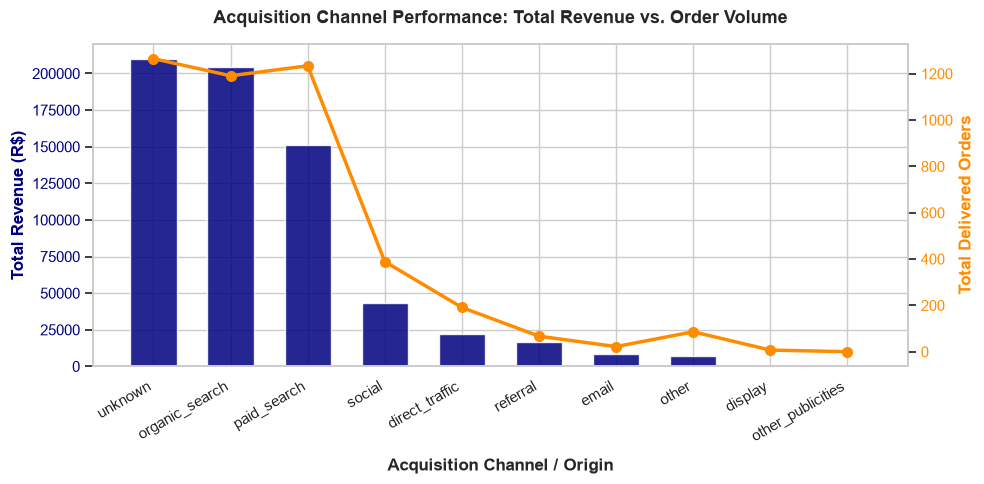

In [85]:
funnel = mql.merge(closed, on="mql_id", how="left")

channel_summary = funnel.groupby("origin").agg(total_mqls=("mql_id", "count"),closed_deals=("seller_id", "count")).reset_index()

channel_sellers = funnel.dropna(subset=["seller_id"]).merge(seller_summary_delivered, on="seller_id", how="left")

channel_perf = channel_sellers.groupby("origin").agg(total_orders=("total_orders", "sum"),total_revenue=("total_revenue", "sum")).reset_index()

channel_df = channel_summary.merge(channel_perf, on="origin", how="left").fillna(0)
channel_df = channel_df.sort_values(by="total_revenue", ascending=False)

fig, ax1 = plt.subplots(figsize=(10, 5))

color = "navy"
ax1.set_xlabel("Acquisition Channel / Origin", fontweight="bold", labelpad=10)
ax1.set_ylabel("Total Revenue (R$)", color=color, fontweight="bold")
bars = ax1.bar(channel_df["origin"], channel_df["total_revenue"], color=color, alpha=0.85, width=0.6)
ax1.tick_params(axis="y", labelcolor=color)
plt.xticks(rotation=30, ha="right")

ax2 = ax1.twinx()
color = "darkorange"
ax2.set_ylabel("Total Delivered Orders", color=color, fontweight="bold")
lines = ax2.plot(channel_df["origin"], channel_df["total_orders"], color=color, marker="o", linewidth=2.5, markersize=7)
ax2.tick_params(axis="y", labelcolor=color)

plt.grid(False)
plt.title("Acquisition Channel Performance: Total Revenue vs. Order Volume", fontsize=13, fontweight="bold", pad=15)
fig.tight_layout()
plt.show()

# Q3

C:\Users\user\AppData\Local\Temp\ipykernel_13748\3042895981.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=top_srs, x="total_seller_revenue", y="sr_short", palette="Purples_r")


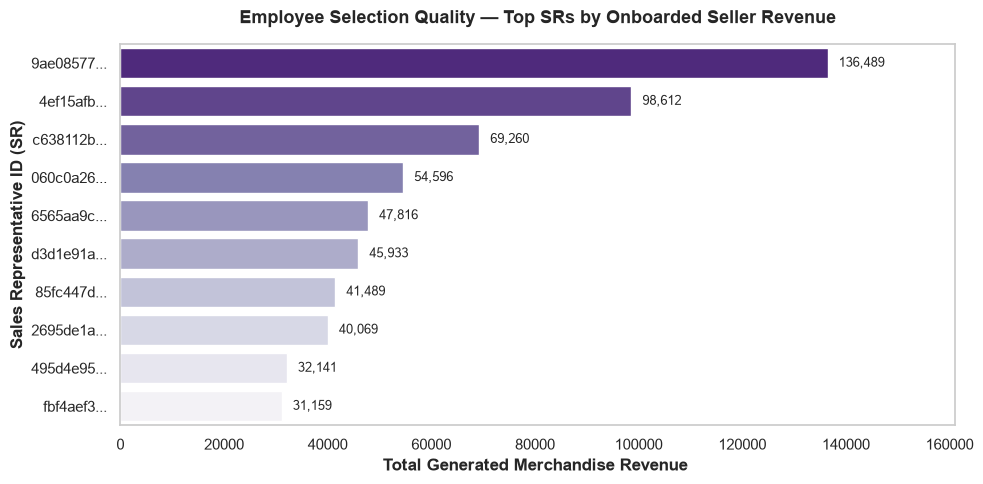

In [86]:
seller_revenue = (order_items.groupby("seller_id")["price"].sum().reset_index().rename(columns={"price": "total_seller_revenue"}))

sr_performance = closed.merge(seller_revenue, on="seller_id", how="left").fillna({"total_seller_revenue": 0})

top_srs = (sr_performance.groupby("sr_id")["total_seller_revenue"].sum().reset_index().sort_values(by="total_seller_revenue", ascending=False).head(10))

top_srs["sr_short"] = top_srs["sr_id"].apply(lambda x: str(x)[:8] + "...")

plt.figure(figsize=(10, 5))
ax = sns.barplot(data=top_srs, x="total_seller_revenue", y="sr_short", palette="Purples_r")

for p in ax.patches:
    width = p.get_width()
    ax.annotate(
        f" {width:,.0f}",
        (width, p.get_y() + p.get_height() / 2.0),
        ha="left",
        va="center",
        fontsize=9,
        xytext=(5, 0),
        textcoords="offset points",)

plt.title("Employee Selection Quality — Top SRs by Onboarded Seller Revenue", fontsize=13, fontweight="bold", pad=15)
plt.xlabel("Total Generated Merchandise Revenue ", fontweight="bold")
plt.ylabel("Sales Representative ID (SR)", fontweight="bold")
plt.xlim(0, top_srs["total_seller_revenue"].max() * 1.18)
plt.tight_layout()
plt.grid(False)
plt.show()

# Q4

C:\Users\user\AppData\Local\Temp\ipykernel_13748\943060937.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_sellers, x="total_revenue", y="seller_label",  palette="Blues_r",ax=ax,)


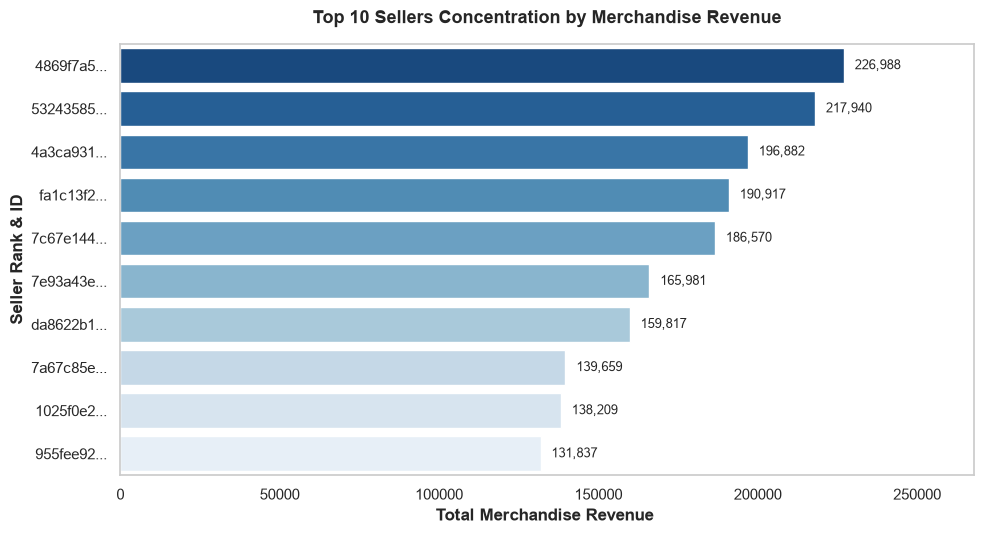

In [66]:
top_10_sellers = (seller_summary.sort_values(by="total_revenue", ascending=False).head(10).copy())

top_10_sellers["seller_label"] = [f"{sid[:8]}..." for i, sid in enumerate(top_10_sellers["seller_id"])]

fig, ax = plt.subplots(figsize=(10, 5.5))
sns.set_theme(style="whitegrid")

sns.barplot(data=top_10_sellers, x="total_revenue", y="seller_label",  palette="Blues_r",ax=ax,)


for p in ax.patches:
    width = p.get_width()
    ax.annotate(
        f" {width:,.0f}",
        (width, p.get_y() + p.get_height() / 2.0),
        ha="left",
        va="center",
        fontsize=9,
        xytext=(5, 0),
        textcoords="offset points",)

ax.set_title("Top 10 Sellers Concentration by Merchandise Revenue", fontsize=13,fontweight="bold",pad=15,)
ax.set_xlabel("Total Merchandise Revenue ", fontweight="bold")
ax.set_ylabel("Seller Rank & ID", fontweight="bold")
ax.set_xlim(0, top_10_sellers["total_revenue"].max() * 1.18)
plt.grid(False)
fig.tight_layout()
plt.show()

# Q5

C:\Users\user\AppData\Local\Temp\ipykernel_13748\3349572367.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=top_red_flags, x="late_delivery_rate_%", y="seller_short", palette="Reds_r")


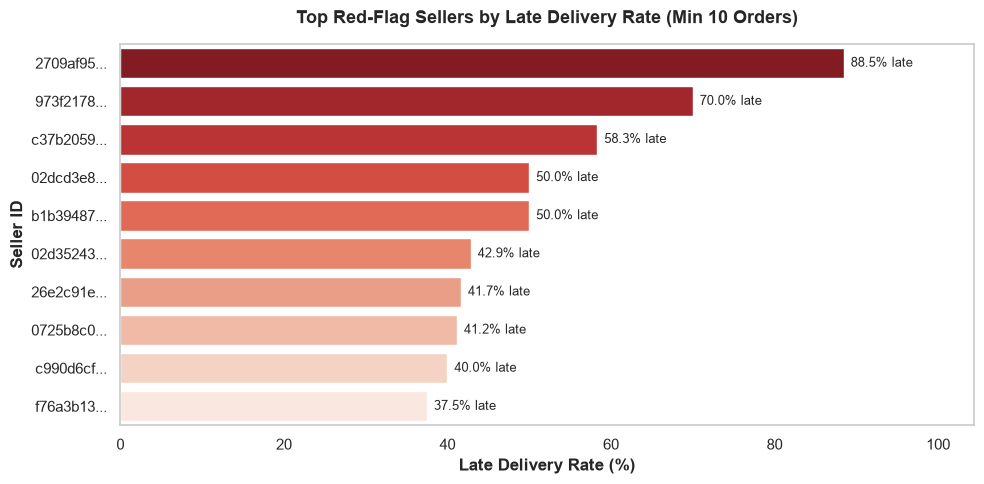

In [62]:
seller_orders = order_items.merge(orders, on="order_id", how="left").merge(reviews, on="order_id", how="left")
seller_orders["delivered_date"] = pd.to_datetime(seller_orders["order_delivered_customer_date"])
seller_orders["estimated_date"] = pd.to_datetime(seller_orders["order_estimated_delivery_date"])
seller_orders["is_late"] = (seller_orders["delivered_date"] > seller_orders["estimated_date"])


seller_flags = (seller_orders.groupby("seller_id").agg(total_orders=("order_id", "nunique"),
                avg_review_score=("review_score", "mean"),late_orders=("is_late", "sum"),).reset_index())

seller_flags["late_delivery_rate_%"] = (seller_flags["late_orders"] / seller_flags["total_orders"]) * 100


red_flag_sellers = seller_flags[(seller_flags["total_orders"] >= 10) & ((seller_flags["avg_review_score"] < 3.0)
| (seller_flags["late_delivery_rate_%"] > 20.0))
].sort_values(by="late_delivery_rate_%", ascending=False)

top_red_flags = red_flag_sellers.head(10).copy()
top_red_flags["seller_short"] = top_red_flags["seller_id"].apply(lambda x: str(x)[:8] + "...")


plt.figure(figsize=(10, 5))
sns.set_theme(style="whitegrid")

ax = sns.barplot(data=top_red_flags, x="late_delivery_rate_%", y="seller_short", palette="Reds_r")


for p in ax.patches:
    width = p.get_width()
    ax.annotate(
        f"{width:.1f}% late",
        (width, p.get_y() + p.get_height() / 2.0),
        ha="left",
        va="center",
        fontsize=9,
        xytext=(5, 0),
        textcoords="offset points",
    )

plt.title( "Top Red-Flag Sellers by Late Delivery Rate (Min 10 Orders)", fontsize=13,fontweight="bold", pad=15,)
plt.xlabel("Late Delivery Rate (%)", fontweight="bold")
plt.ylabel("Seller ID", fontweight="bold")
plt.xlim(0, top_red_flags["late_delivery_rate_%"].max() * 1.18)
plt.tight_layout()
plt.grid(False)

plt.show()

# Q6

C:\Users\user\AppData\Local\Temp\ipykernel_13748\619477572.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=type_summary, x="business_type", y="total_orders", palette="Set2", ax=ax1)
C:\Users\user\AppData\Local\Temp\ipykernel_13748\619477572.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=type_summary, x="business_type", y="avg_order_value", palette="Set2", ax=ax2,)


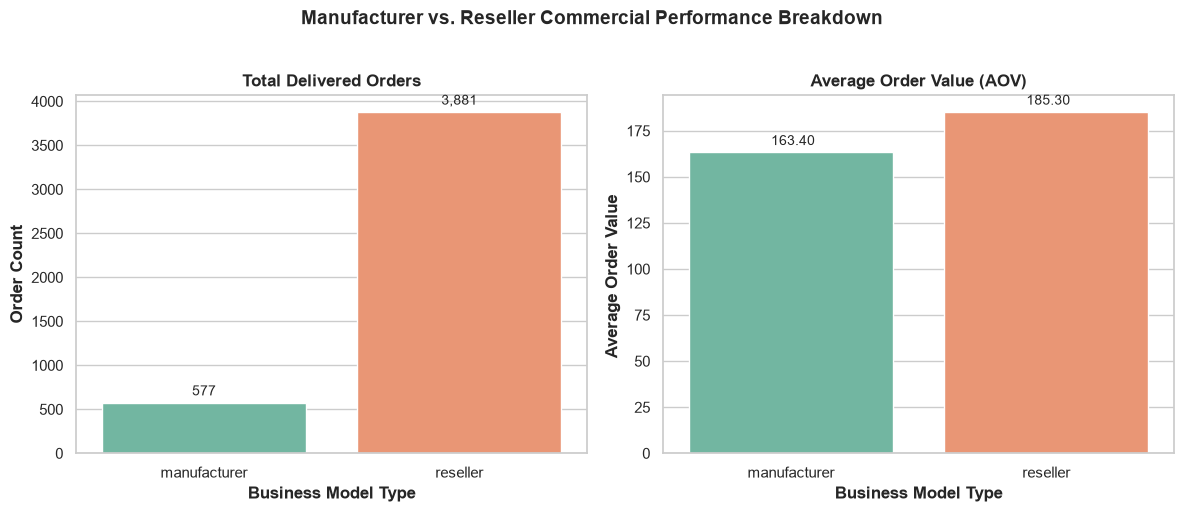

In [88]:
biz_summary = closed.merge(seller_summary, on="seller_id", how="inner")
type_summary = (
    biz_summary.groupby("business_type").agg(
        seller_count=("seller_id", "nunique"),
        total_orders=("total_orders", "sum"),
        total_revenue=("total_revenue", "sum"),
        avg_order_value=("avg_order_value", "mean"),).reset_index())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(data=type_summary, x="business_type", y="total_orders", palette="Set2", ax=ax1)
ax1.set_title("Total Delivered Orders", fontweight="bold")
ax1.set_xlabel("Business Model Type", fontweight="bold")
ax1.set_ylabel("Order Count", fontweight="bold")

for p in ax1.patches:
    ax1.annotate(
        f"{int(p.get_height()):,}",
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=10,
        xytext=(0, 3),
        textcoords="offset points",)


sns.barplot(data=type_summary, x="business_type", y="avg_order_value", palette="Set2", ax=ax2,)
ax2.set_title("Average Order Value (AOV)", fontweight="bold")
ax2.set_xlabel("Business Model Type", fontweight="bold")
ax2.set_ylabel("Average Order Value ", fontweight="bold")

for p in ax2.patches:
    ax2.annotate(
        f" {p.get_height():.2f}",
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=10,
        xytext=(0, 3),
        textcoords="offset points",)

plt.suptitle("Manufacturer vs. Reseller Commercial Performance Breakdown",fontsize=14,fontweight="bold",y=1.02,)
fig.tight_layout()
plt.show()